In [19]:
import kagglehub
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

# Целевая переменная: Price 
cache_path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")

csv_filename = [f for f in os.listdir(cache_path) if f.endswith('.csv')][0]
source_file = os.path.join(cache_path, csv_filename)

local_file_name = 'toyota_data.csv'
shutil.copy(source_file, local_file_name)

dataset = pd.read_csv('toyota_data.csv')
# Уберем, тк он не нужен 
dataset.drop('Id', axis=1, inplace=True)
# Переименуем в Age
dataset.rename(columns={'Age_08_04': 'Age'}, inplace=True) 
dataset.head(3)


,Model,Price,Age,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0


In [20]:
print("Количество записей:\n", dataset.count())
print("\nСтатистика:\n", dataset.describe())
print("\nПропуски:\n", dataset.isnull().sum())


Количество записей:
 Model                1436
Price                1436
Age                  1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistant    1436
Tow_Bar          

EDA


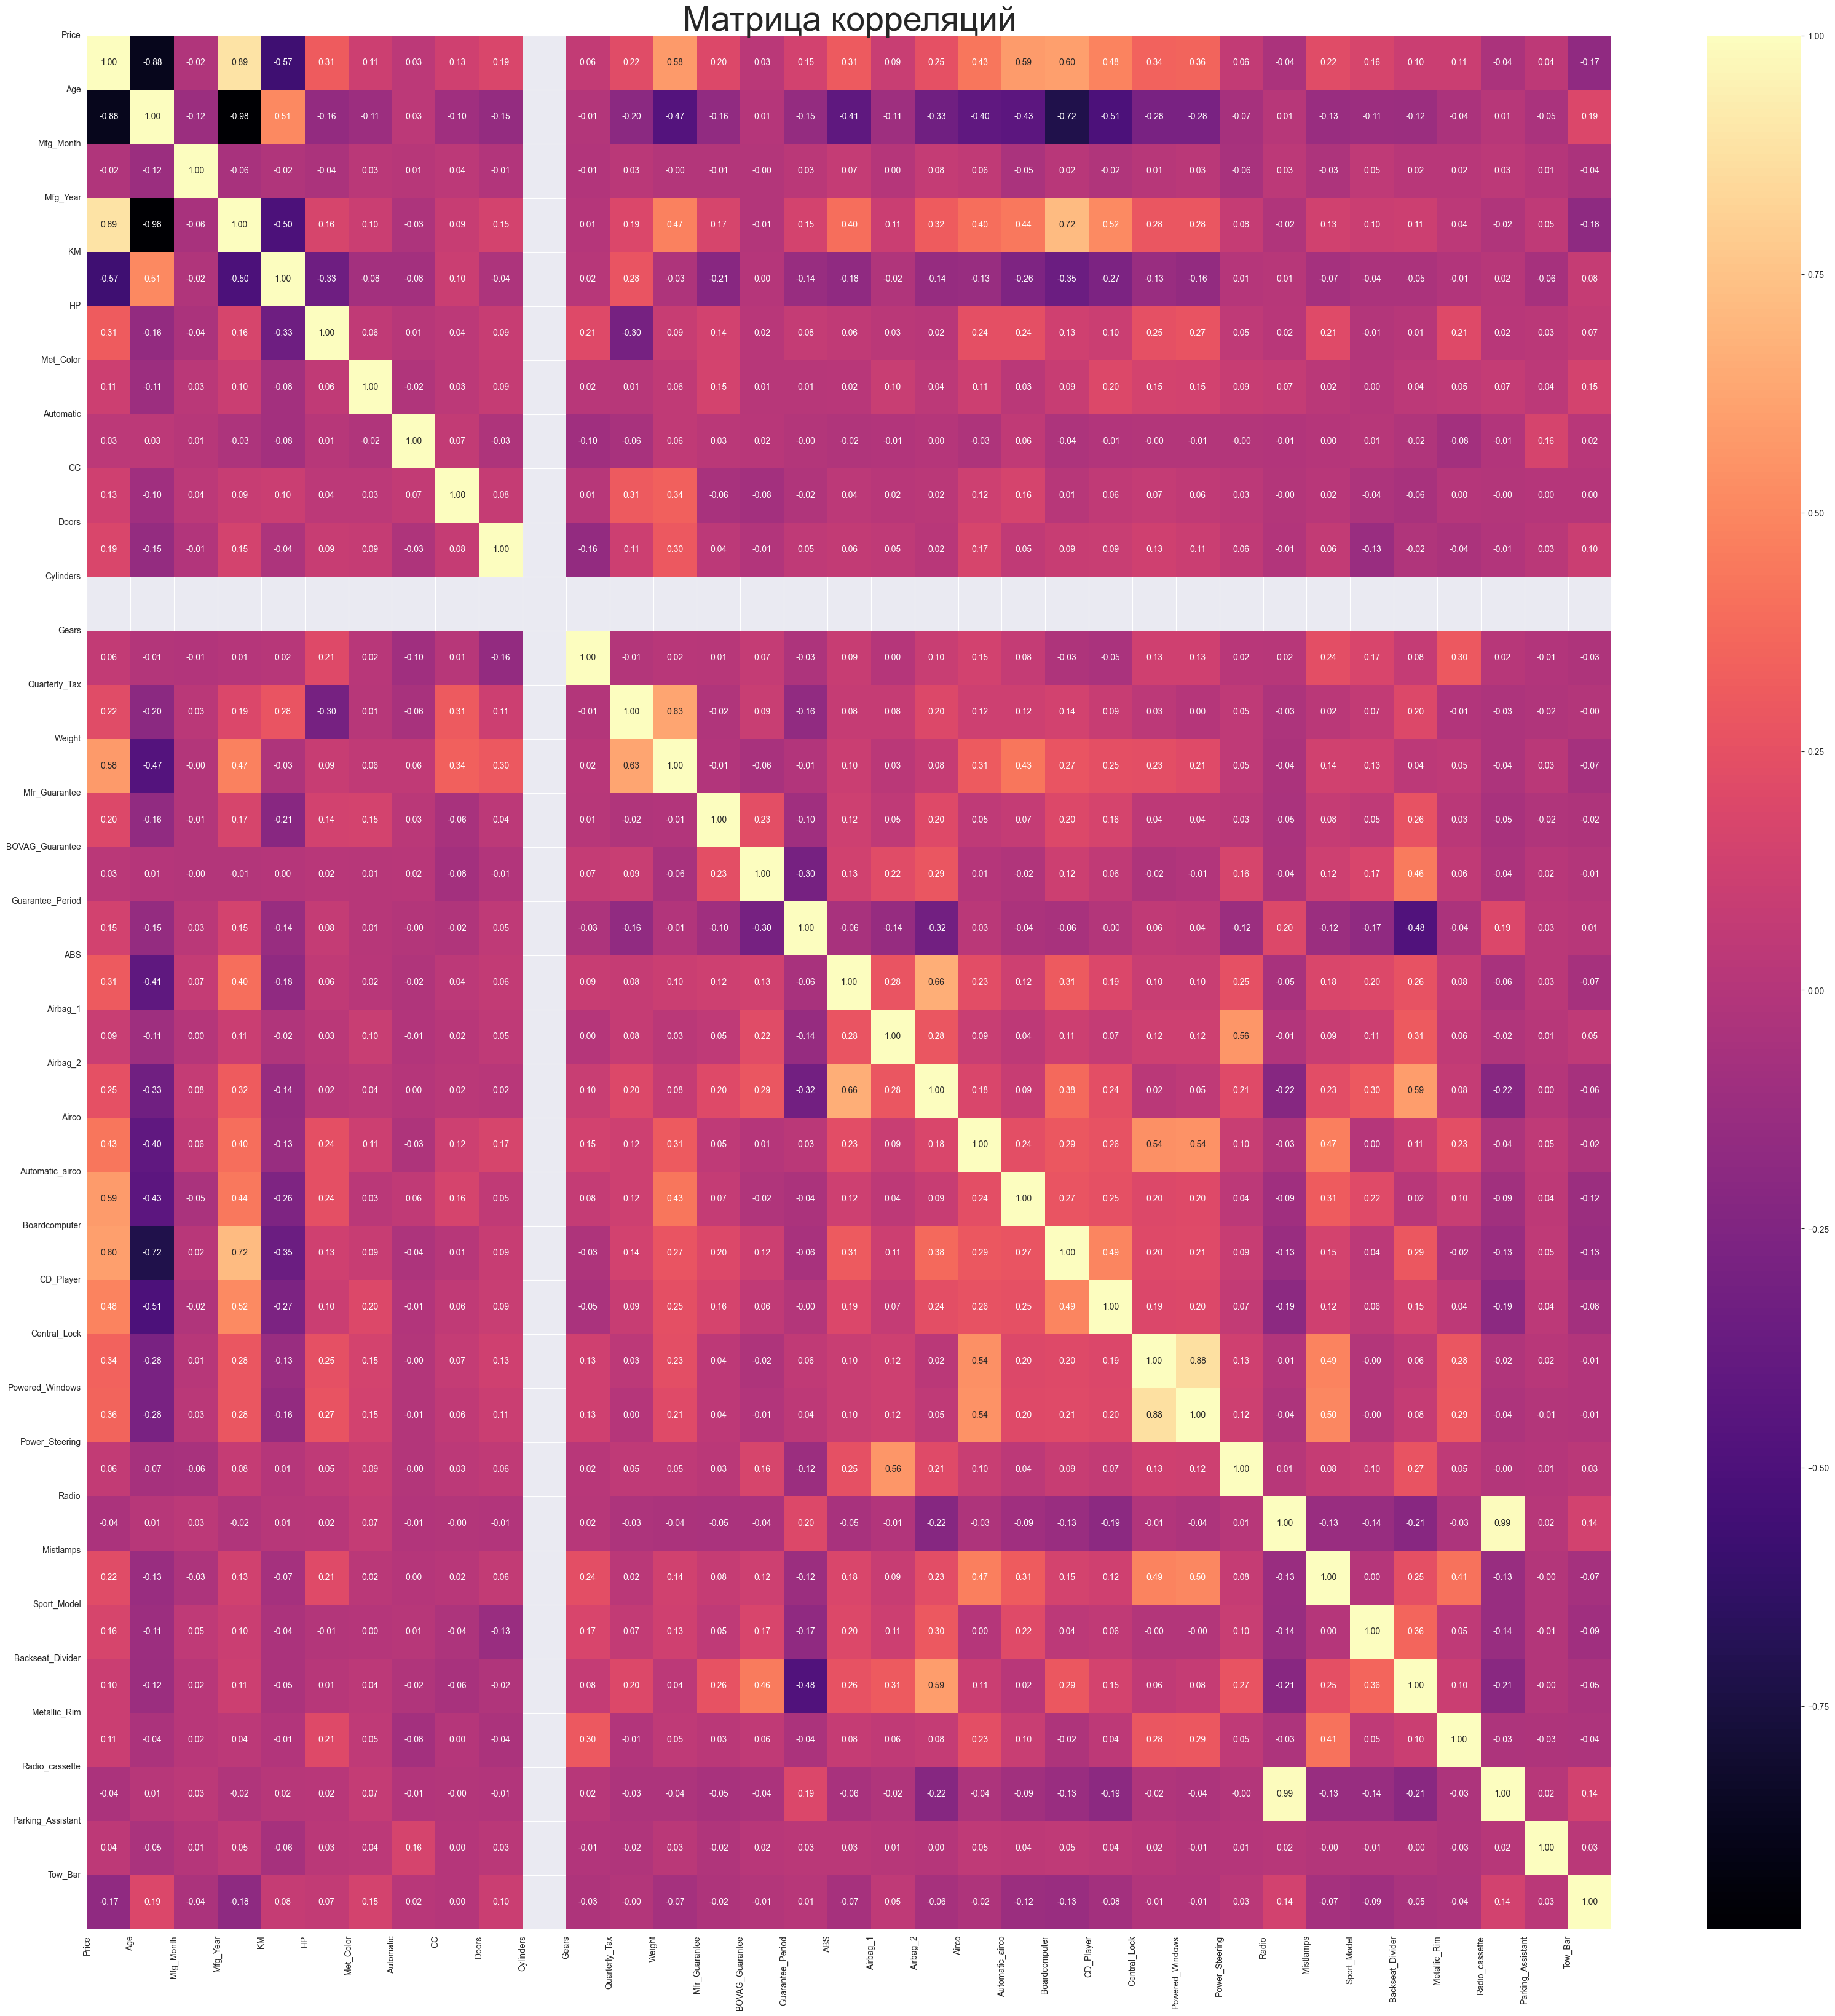

In [21]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(40, 40))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций", fontsize=40)
plt.show()


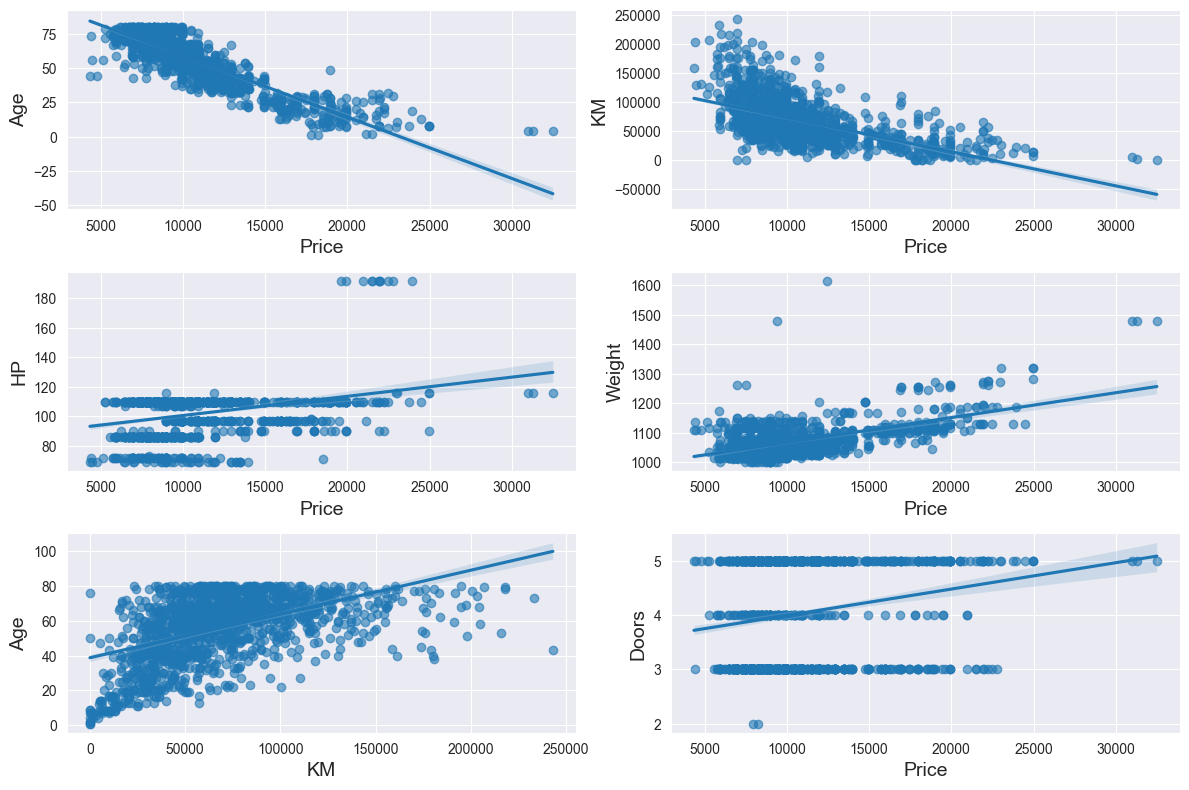

In [22]:
f, axes = plt.subplots(3, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='HP', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('HP', fontsize=14)

sns.regplot(x='Price', y='Weight', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('Weight', fontsize=14)

sns.regplot(x='KM', y='Age', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[2,0])
axes[2,0].set_xlabel('KM', fontsize=14)
axes[2,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='Doors', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[2,1])
axes[2,1].set_xlabel('Price', fontsize=14)
axes[2,1].set_ylabel('Doors', fontsize=14)

plt.tight_layout()
plt.show()

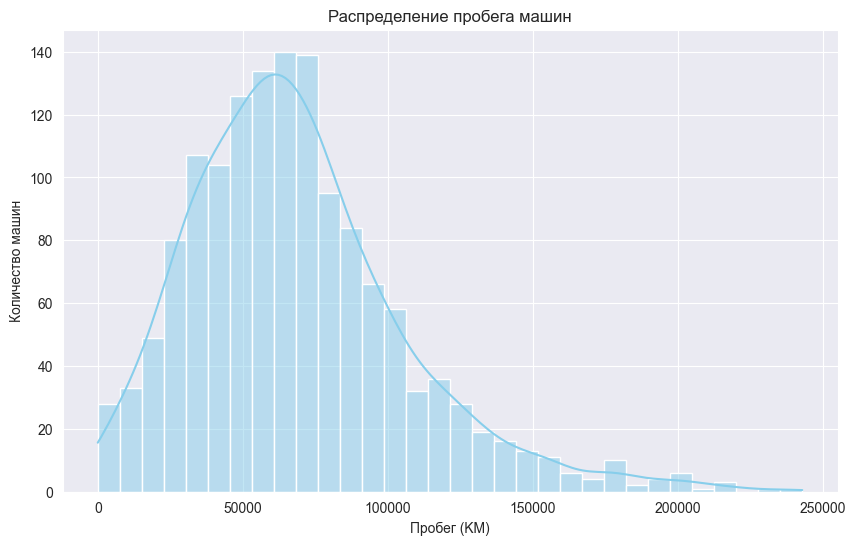

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(x='KM', data=dataset, kde=True, color='skyblue')

plt.title('Распределение пробега машин')
plt.xlabel('Пробег (KM)')
plt.ylabel('Количество машин')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

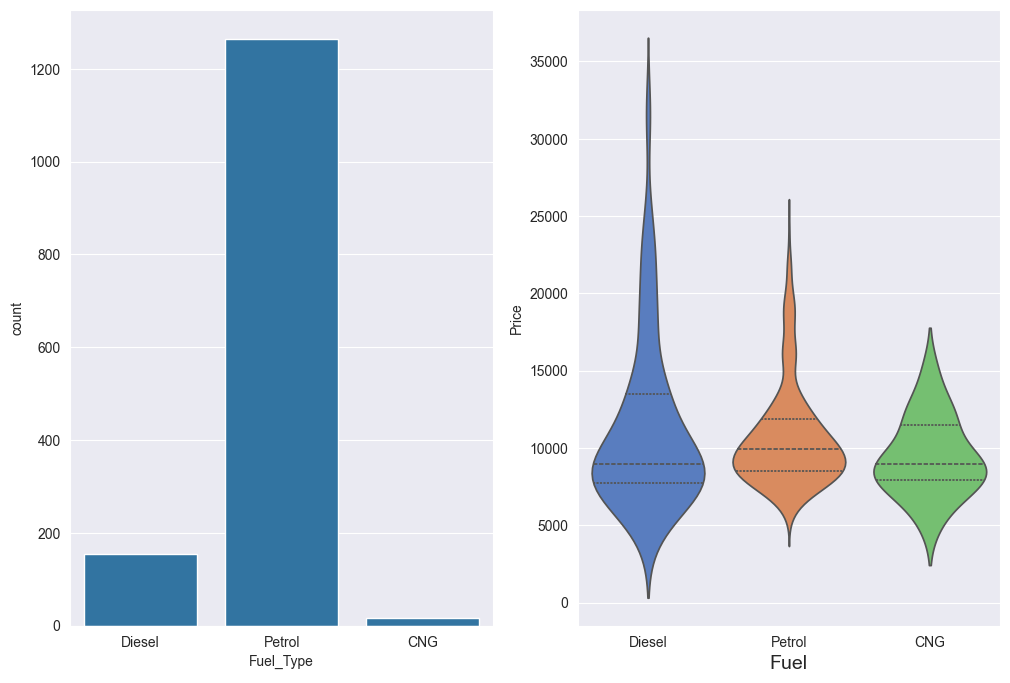

In [24]:

f, axes = plt.subplots(1, 2, figsize=(12,8))

sns.countplot(x='Fuel_Type', data=dataset, ax=axes[0])
axes[1].set_xlabel('Fuel', fontsize=14)

sns.violinplot(x='Fuel_Type', y='Price', data=dataset, palette='muted', inner='quartile', ax=axes[1])
axes[1].set_xlabel('Fuel', fontsize=14)

plt.show


Как я предобрабатывал данные? 
    Никак, тк не было пропусков, дубликатов.  Но в папке hw_test_setup_tools был датасет про учеников, где я заполнял пропуски. 
  
Что вы поняли, проведя EDA?
    В датасете есть выбросы (например при возрасти почти 80 месяцев пробег 0) и есть шанс шума(пара машин с hp 190). EDA показал сильную отрицательную корреляцию цены с возрастом и пробегом, а также выявил различия в стоимости машин в зависимости от типа топлива. 



3 Feature engineering

Можно убрать 'Model', 'Mfg_Month', 'Mfg_Year', 'Met_Color', 'Automatic', 'CC', 'Color', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',          'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Automatic_airco',
              'CD_Player', 'Central_Lock',  'Powered_Windows','Power_Steering', 'Radio', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Boardcomputer', 'Radio_cassette', 'Mistlamps', 'Parking_Assistant', 'Tow_Bar'

Чтобы оставить главыне фичи

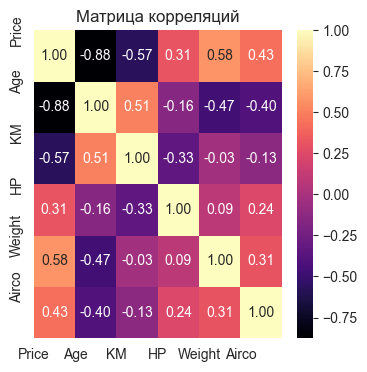

In [25]:
dataset.drop(['Model', 'Mfg_Month', 'Mfg_Year', 'Met_Color', 'Automatic', 'CC', 'Color', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Automatic_airco',
              'CD_Player', 'Central_Lock',  'Powered_Windows','Power_Steering', 'Radio', 'Sport_Model', 'Backseat_Divider',
              'Metallic_Rim', 'Boardcomputer', 'Radio_cassette', 'Mistlamps', 'Parking_Assistant', 'Tow_Bar'], 
              axis=1, inplace=True)

corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

In [26]:
dataset = pd.get_dummies(dataset, drop_first=True)
dataset.head(3)

,Price,Age,KM,HP,Weight,Airco,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,1165,0,True,False
1,13750,23,72937,90,1165,1,True,False
2,13950,24,41711,90,1165,0,True,False


Как вы работали с признаками?
    Удалил избыточные признаки(которые имели слабую корреляцию с ценой). Сделал One-Hot Encoding для топлива. Убрал мультиколлинеарность(год выпуска и возраст машины на данную дату).

Какие признаки вы добавили / изменили и почему?
    Перевел топливо в бинарный вектор, тк он являлся категориальным.

Какие признаки вы удалили и почему?
    'Model', 'Mfg_Month', 'Mfg_Year', 'Met_Color', 'Automatic', 'CC', 'Color', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',  'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Automatic_airco', 'CD_Player', 'Central_Lock',  'Powered_Windows','Power_Steering', 'Radio', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Boardcomputer', 'Radio_cassette', 'Mistlamps', 'Parking_Assistant'

Тк они имеют слабую корреляцию с ценой, что позволяет снизить риск переобучения и оставить реально важные факторы.

4. Разделение выборки

In [27]:
X = dataset.drop('Price', axis=1).values
y = dataset['Price'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Размер X_train: ", X_train.shape)
print("Размер X_test: ", X_test.shape)

Размер X_train:  (1077, 7)
Размер X_test:  (359, 7)


Как именно вы разделили выборку?
    Сделал матрицу признаков, убрав из датасета Price. А также превратил колонку pandas в массив numpy.
    Сделал целевой вектор Price. Превратил колонку pandas в массив numpy и сделал столбец из него.
    Выборку разделил 75% на train и 25% на тест(тк строк 1500, если было бы больше строк, например 1млн, то выбрал бы 1%, если - 100 строк, то 10%-15%); random_state=42, чтобы получать тот же результат при каждом запуске.

Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?
    Это надо для того, чтобы оценивать качество модели на данных, которые она еще не видила, для которых и мы строим эту модель. 
    Если обучать и проверять модель на одних и том же наборе данных, то модель может просто переобучиться (просто выучить ответы, т.е. не сможет найти закономерности). И когда мы будем давать ей новые данные, то ответ будет далек от истины. А если обучать и проверять на разных выборках,то шанс переобучения меньше и можно понять насколько хорошо будет модель на новых данных.


5 Обучение

In [29]:
linear_model = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())    
]

regressor = Pipeline(linear_model)
regressor.fit(X_train, y_train)

y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

rmse_linear_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_linear_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mape_linear_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_linear_test = mean_absolute_percentage_error(y_test, y_test_pred)


r2_linear_train = r2_score(y_train, y_train_pred)
r2_linear_test = r2_score(y_test, y_test_pred)

cv = cross_val_score(estimator=regressor, X = X_train, y = y_train, cv=10, scoring='neg_mean_absolute_percentage_error')

print("Linear Regression:\n")
print("CV mean:", cv.mean())
print("RMSE train: ", rmse_linear_train)
print("RMSE test: ", rmse_linear_test)
print("MAPE train:", mape_linear_train)
print("MAPE test: ", mape_linear_test)
print("R2 train: ", r2_linear_train)
print('R2 test: ', r2_linear_test)


Linear Regression:

CV mean: -0.08519869316090635
RMSE train:  1069.5878041756855
RMSE test:  1269.9341362522339
MAPE train: 0.08121211072873448
MAPE test:  0.08925763566220836
R2 train:  0.9105838182809199
R2 test:  0.8863543474991732


1. Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?). MAPE тк цены на второчином рынке - это желание продавца, ничего не запрещает ему зависить или занизить цену. R^2 нужен для того, какую долю дисперсии целевой переменной объясняет модель.
2. На какой части выборки вы считали метрики? На обучающей и тестовой выборке
3. Какая модель по итогу справилась лучше? -
4. Насколько хорошие получились результаты? Разница 9 процентов на тесте, что вполне приемлимо, учитывая, что это вторичный рынок
5. Чем докажете, что ваша модель не переобучилась? Показания на тестовой и обучающей выборках близки.